In [1]:
import pandas as pd


In [2]:
df=pd.read_csv("bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
df["age"].describe()

count    11162.000000
mean        41.231948
std         11.913369
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64

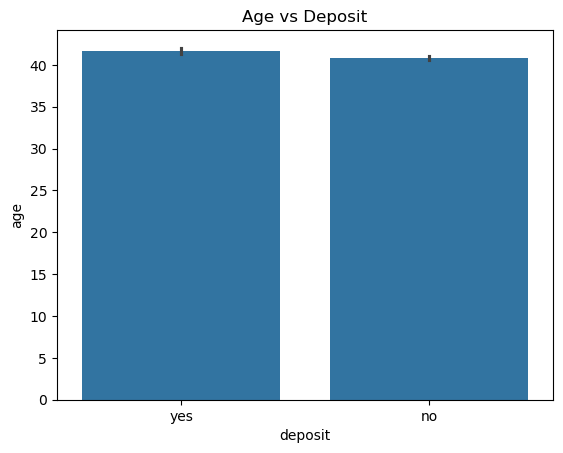

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="deposit", y="age", data=df)
plt.title("Age vs Deposit")
plt.show()

In [12]:
df.groupby(["age", "deposit"]).size().reset_index(name="count")

,age,deposit,count
0,18,no,1
1,18,yes,7
2,19,no,2
3,19,yes,11
4,20,no,5
...,...,...,...
139,89,no,1
140,90,yes,2
141,92,yes,2
142,93,yes,2


In [13]:
pivot = df.pivot_table(
    index="age",
    columns="deposit",
    aggfunc="size",
    fill_value=0
)

pivot

deposit,no,yes
age,,
18,1,7
19,2,11
20,5,15
21,8,22
22,8,40
...,...,...
89,1,0
90,0,2
92,0,2


In [14]:
pivot_percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_percent

deposit,no,yes
age,,
18,12.500000,87.500000
19,15.384615,84.615385
20,25.000000,75.000000
21,26.666667,73.333333
22,16.666667,83.333333
...,...,...
89,100.000000,0.000000
90,0.000000,100.000000
92,0.000000,100.000000


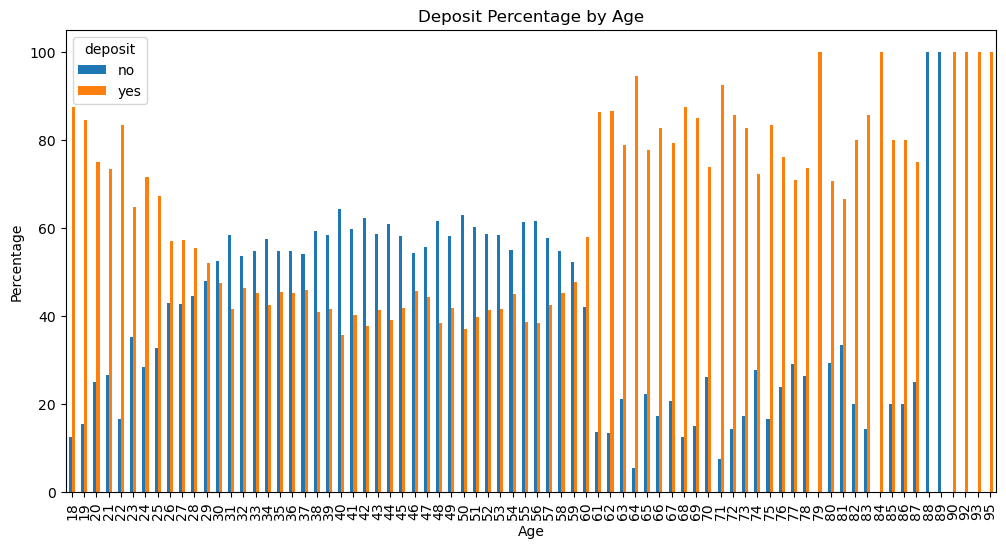

In [15]:
pivot_percent.plot(kind="bar", figsize=(12,6))
plt.title("Deposit Percentage by Age")
plt.xlabel("Age")
plt.ylabel("Percentage")
plt.show()